# TRL Capacity Auction Analysis — March 2026

Analysis of the daily TRL (Tertiärregelleistung) capacity auction results for March 2026.
Data source: `2026-PRL-SRL-TRL-Ergebnis.csv`

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1. Load & Parse Data

Individual bid data for PRL, SRL and TRL capacity auctions. We filter for TRL daily auction codes (`TRL_26_03_xx`) and extract direction, date and 4-hour time block from the `Ausschreibung` and `Beschreibung` columns.

In [34]:
DATA_PATH = "TRL Data/2026-PRL-SRL-TRL-Ergebnis.csv"

raw = pd.read_csv(DATA_PATH, sep=None, engine="python", encoding_errors="replace")

# Keep only TRL daily auction codes: TRL_26_MM_DD
trl = raw[raw["Ausschreibung"].str.match(r"TRL_26_\d{2}_\d{2}", na=False)].copy()

# Parse date from auction code (TRL_26_03_01 → 2026-03-01)
trl["Date"] = pd.to_datetime(
    trl["Ausschreibung"].str.extract(r"TRL_26_(\d{2})_(\d{2})").apply(
        lambda r: f"2026-{r[0]}-{r[1]}", axis=1
    )
)

# Parse direction and time block from Beschreibung
# e.g. "Tertiary Power DOWN 00:00 bis 04:00"
trl["Direction"] = trl["Beschreibung"].str.extract(r"(UP|DOWN)")
trl["Block"]     = trl["Beschreibung"].str.extract(r"(\d{2}:\d{2} bis \d{2}:\d{2})")

# Filter for March
march = trl[trl["Date"].dt.month == 3].copy()

# Rename for convenience
march = march.rename(columns={
    "Angebotenes Volumen":   "Bid_MW",
    "Zugesprochenes Volumen": "Acc_MW",
    "Leistungspreis":        "Leistungspreis",
})

march["Accepted"] = march["Acc_MW"] > 0

print(f"March TRL daily bids: {len(march):,}")
print(f"Directions: {march['Direction'].value_counts().to_dict()}")
print(f"Time blocks: {sorted(march['Block'].dropna().unique())}")
print(f"\nSample:")
print(march[["Date","Direction","Block","Bid_MW","Acc_MW","Leistungspreis"]].head(8).to_string(index=False))

March TRL daily bids: 2,733
Directions: {'DOWN': 1639, 'UP': 1094}
Time blocks: ['00:00 bis 04:00', '04:00 bis 08:00', '08:00 bis 12:00', '12:00 bis 16:00', '16:00 bis 20:00', '20:00 bis 24:00']

Sample:
      Date Direction           Block  Bid_MW  Acc_MW  Leistungspreis
2026-03-01      DOWN 00:00 bis 04:00       6       0            2.80
2026-03-01      DOWN 00:00 bis 04:00       5       0           60.00
2026-03-01      DOWN 00:00 bis 04:00      79      54            3.48
2026-03-01      DOWN 00:00 bis 04:00     100       0          100.00
2026-03-01      DOWN 00:00 bis 04:00      55       0           10.00
2026-03-01      DOWN 00:00 bis 04:00      10       0            2.00
2026-03-01      DOWN 00:00 bis 04:00       5       0            2.40
2026-03-01      DOWN 04:00 bis 08:00       6       0            2.76


## 2. Summary Statistics — March 2026

In [35]:
for direction in ["UP", "DOWN"]:
    df = march[march["Direction"] == direction]
    acc = df[df["Accepted"]]
    print(f"── TRL {direction} ──")
    print(f"  Total bids           : {len(df):,}")
    print(f"  Accepted bids        : {len(acc):,}  ({len(acc)/len(df):.1%})")
    print(f"  Total bid vol        : {df['Bid_MW'].sum():,.0f} MW")
    print(f"  Total accepted vol   : {acc['Acc_MW'].sum():,.0f} MW")
    print(f"  Leistungspreis (all bids)")
    print(f"    Median             : {df['Leistungspreis'].median():>8.1f} CHF/MW")
    print(f"    Mean               : {df['Leistungspreis'].mean():>8.1f} CHF/MW")
    print(f"  Leistungspreis (accepted only)")
    print(f"    Median             : {acc['Leistungspreis'].median():>8.1f} CHF/MW")
    print(f"    Mean               : {acc['Leistungspreis'].mean():>8.1f} CHF/MW")
    print(f"    Max (marginal)     : {acc['Leistungspreis'].max():>8.1f} CHF/MW")
    print()

── TRL UP ──
  Total bids           : 1,094
  Accepted bids        : 392  (35.8%)
  Total bid vol        : 36,892 MW
  Total accepted vol   : 8,919 MW
  Leistungspreis (all bids)
    Median             :     15.5 CHF/MW
    Mean               :     51.9 CHF/MW
  Leistungspreis (accepted only)
    Median             :     10.0 CHF/MW
    Mean               :     13.0 CHF/MW
    Max (marginal)     :     64.0 CHF/MW

── TRL DOWN ──
  Total bids           : 1,639
  Accepted bids        : 512  (31.2%)
  Total bid vol        : 42,887 MW
  Total accepted vol   : 8,718 MW
  Leistungspreis (all bids)
    Median             :      9.0 CHF/MW
    Mean               :     29.0 CHF/MW
  Leistungspreis (accepted only)
    Median             :      4.5 CHF/MW
    Mean               :      5.6 CHF/MW
    Max (marginal)     :     46.0 CHF/MW



## 3. Daily Offered vs. Accepted Volume — March 2026

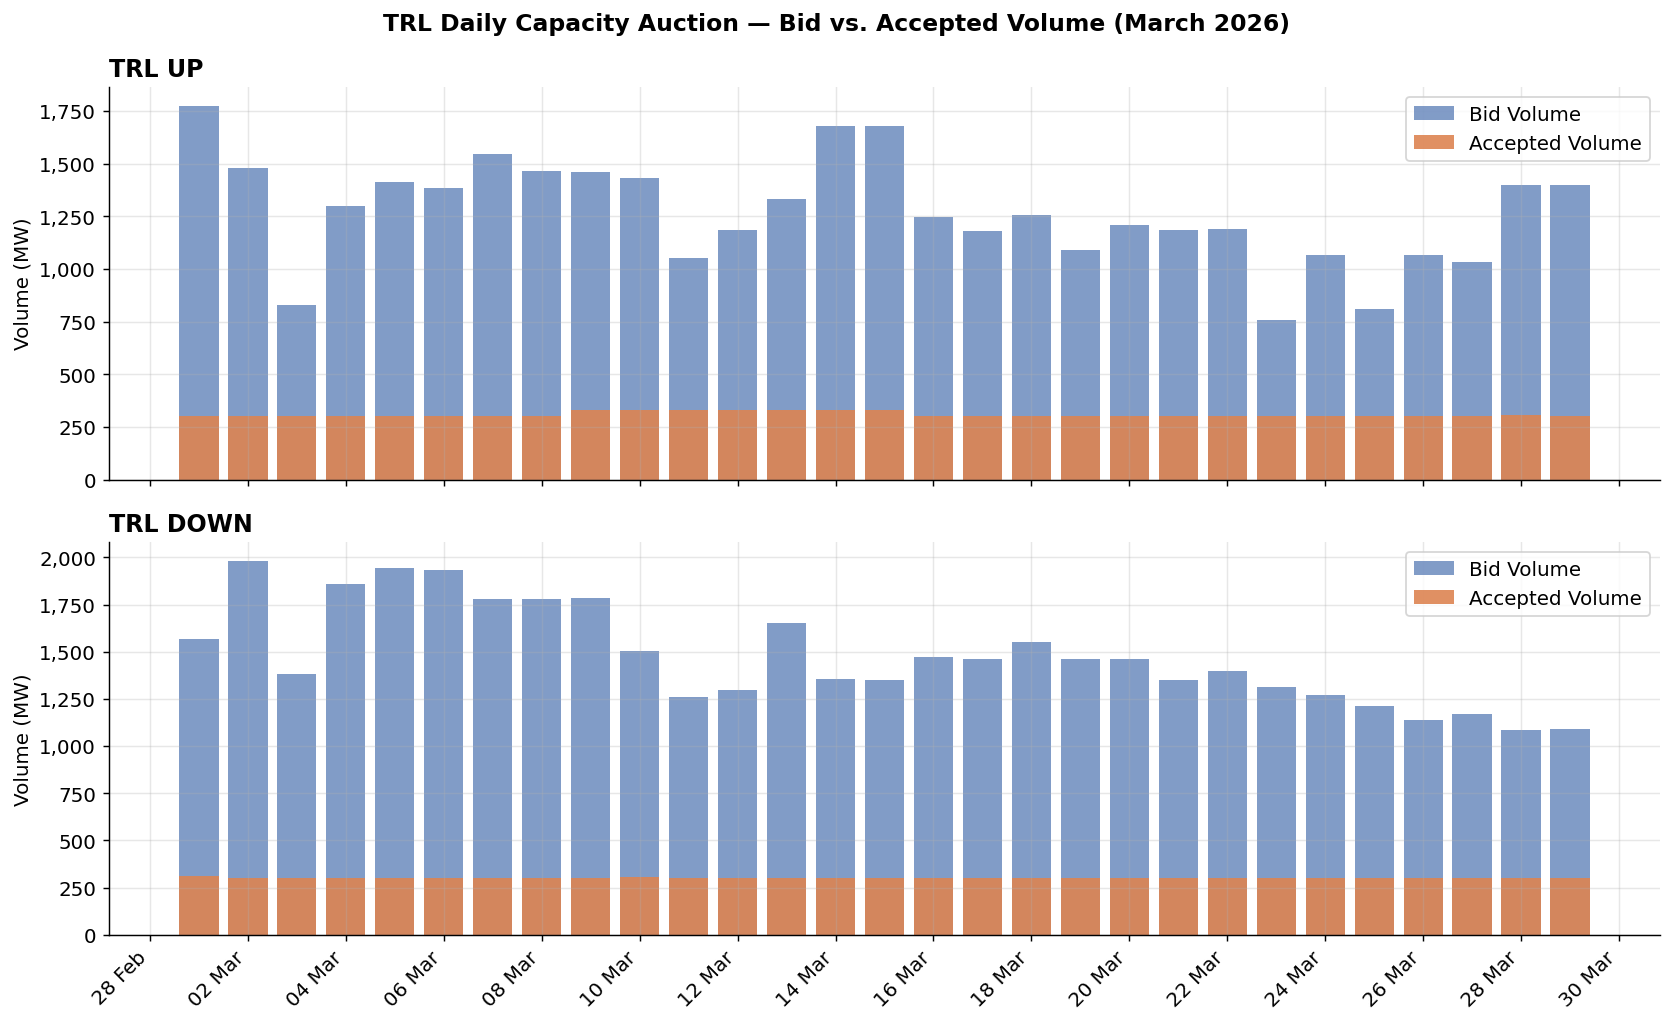

In [36]:
# Aggregate to daily totals per direction
daily = (
    march.groupby(["Date", "Direction"])
    .agg(Bid_MW=("Bid_MW", "sum"), Acc_MW=("Acc_MW", "sum"))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
colors = {"bid": "#4C72B0", "acc": "#DD8452"}

for ax, direction in zip(axes, ["UP", "DOWN"]):
    df = daily[daily["Direction"] == direction]
    ax.bar(df["Date"], df["Bid_MW"], label="Bid Volume",      color=colors["bid"], alpha=0.7, width=0.8)
    ax.bar(df["Date"], df["Acc_MW"], label="Accepted Volume", color=colors["acc"], alpha=0.9, width=0.8)
    ax.set_title(f"TRL {direction}", fontweight="bold", loc="left")
    ax.set_ylabel("Volume (MW)")
    ax.legend(loc="upper right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
axes[-1].xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")

fig.suptitle("TRL Daily Capacity Auction — Bid vs. Accepted Volume (March 2026)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 4. Acceptance Rate Over March

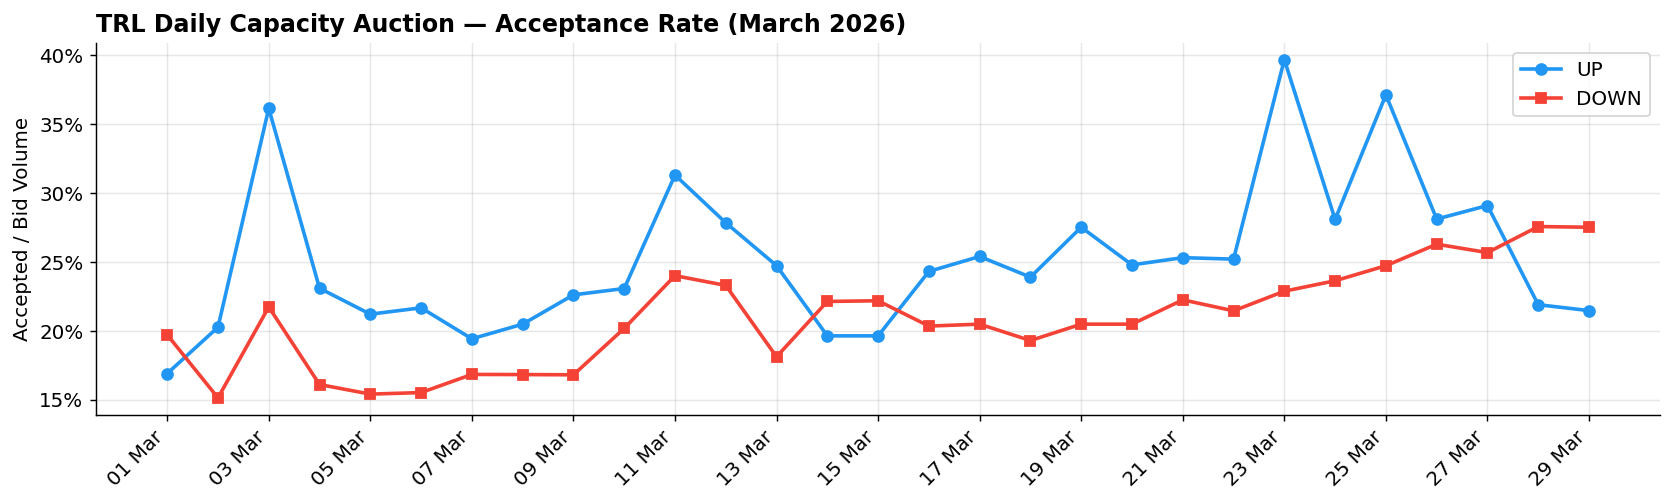

In [37]:
daily["Acc_Rate"] = daily["Acc_MW"] / daily["Bid_MW"]

fig, ax = plt.subplots(figsize=(13, 4))
for direction, marker, color in [("UP", "o", "#2196F3"), ("DOWN", "s", "#F44336")]:
    df = daily[daily["Direction"] == direction]
    ax.plot(df["Date"], df["Acc_Rate"], marker=marker, label=direction, color=color, linewidth=2)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.set_title("TRL Daily Capacity Auction — Acceptance Rate (March 2026)", fontweight="bold", loc="left")
ax.set_ylabel("Accepted / Bid Volume")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Marginal Clearing Price Over March

The marginal price per block is the **highest accepted Leistungspreis** — the most expensive capacity that was still cleared.

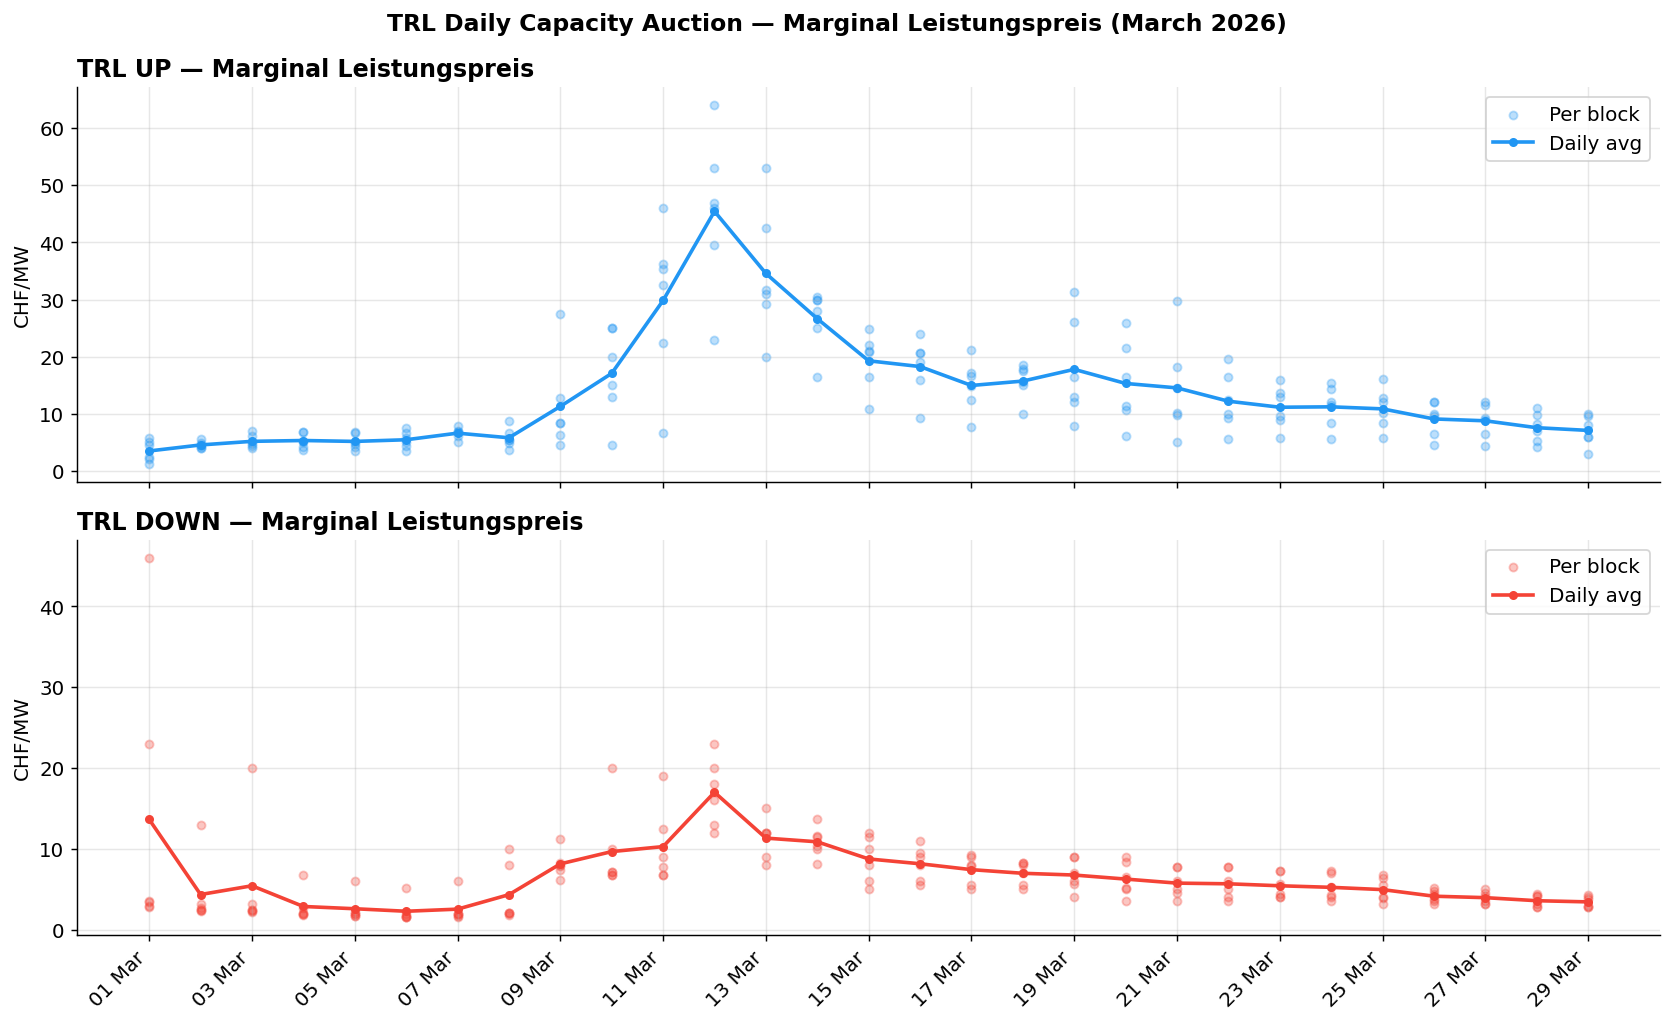

In [38]:
# Marginal price = highest accepted Leistungspreis per date + block + direction
accepted = march[march["Accepted"]]
marginal = (
    accepted.groupby(["Date", "Block", "Direction"])["Leistungspreis"]
    .max()
    .reset_index()
    .rename(columns={"Leistungspreis": "Marginal_Price"})
)

# Daily average marginal price across all blocks
daily_marginal = (
    marginal.groupby(["Date", "Direction"])["Marginal_Price"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for ax, direction, color in zip(axes, ["UP", "DOWN"], ["#2196F3", "#F44336"]):
    dm = daily_marginal[daily_marginal["Direction"] == direction]
    # Individual block marginal prices as scatter
    bm = marginal[marginal["Direction"] == direction]
    ax.scatter(bm["Date"], bm["Marginal_Price"], color=color, alpha=0.3, s=20, label="Per block")
    # Daily average as line
    ax.plot(dm["Date"], dm["Marginal_Price"], color=color, linewidth=2, marker="o", markersize=4, label="Daily avg")
    ax.set_title(f"TRL {direction} — Marginal Leistungspreis", fontweight="bold", loc="left")
    ax.set_ylabel("CHF/MW")
    ax.legend()

axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
axes[-1].xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")

fig.suptitle("TRL Daily Capacity Auction — Marginal Leistungspreis (March 2026)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 7. Key Findings

## 6. Marginal Price by Time Block

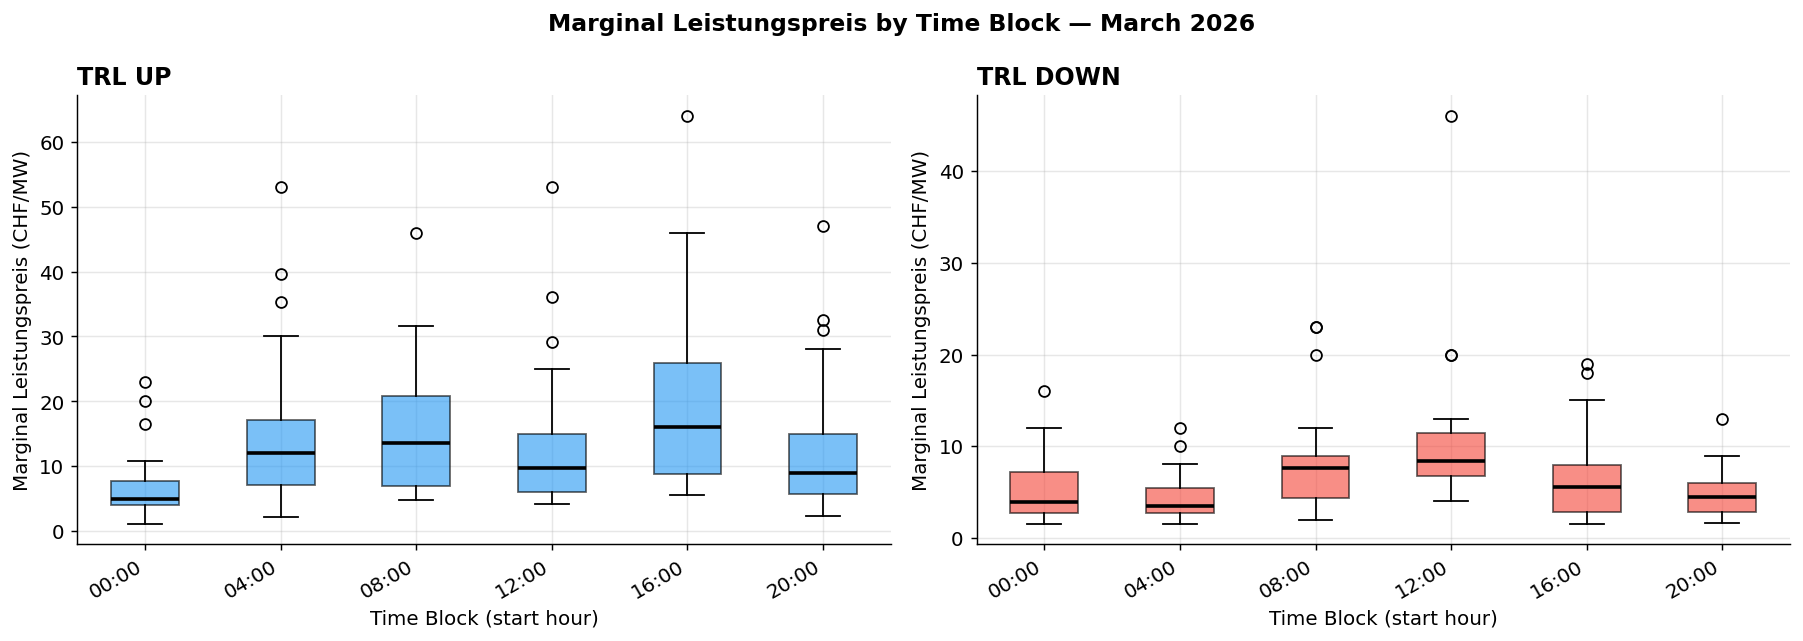

In [39]:
block_order = ["00:00 bis 04:00", "04:00 bis 08:00", "08:00 bis 12:00",
               "12:00 bis 16:00", "16:00 bis 20:00", "20:00 bis 24:00"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, direction, color in zip(axes, ["UP", "DOWN"], ["#2196F3", "#F44336"]):
    data = [
        marginal[(marginal["Direction"] == direction) & (marginal["Block"] == b)]["Marginal_Price"].values
        for b in block_order
    ]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticks(range(1, 7))
    ax.set_xticklabels([b[:5] for b in block_order], rotation=30, ha="right")
    ax.set_title(f"TRL {direction}", fontweight="bold", loc="left")
    ax.set_ylabel("Marginal Leistungspreis (CHF/MW)")
    ax.set_xlabel("Time Block (start hour)")

fig.suptitle("Marginal Leistungspreis by Time Block — March 2026", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [40]:
print("=" * 60)
print("  TRL Daily Capacity Auction — Key Findings (March 2026)")
print("=" * 60)

for direction in ["UP", "DOWN"]:
    df  = march[march["Direction"] == direction]
    acc = df[df["Accepted"]]
    mg  = marginal[marginal["Direction"] == direction]
    dm  = daily_marginal[daily_marginal["Direction"] == direction]

    print(f"\n  {direction}")
    print(f"    Bids / accepted          : {len(df):,} / {len(acc):,}  ({len(acc)/len(df):.1%})")
    print(f"    Avg daily accepted vol   : {daily[daily['Direction']==direction]['Acc_MW'].mean():>7.0f} MW")
    print(f"    Marginal Leistungspreis")
    print(f"      Median (all blocks)    : {mg['Marginal_Price'].median():>7.1f} CHF/MW")
    print(f"      Mean   (all blocks)    : {mg['Marginal_Price'].mean():>7.1f} CHF/MW")
    print(f"      Min                    : {mg['Marginal_Price'].min():>7.1f} CHF/MW  ({mg.loc[mg['Marginal_Price'].idxmin(), 'Date'].date()}, {mg.loc[mg['Marginal_Price'].idxmin(), 'Block']})")
    print(f"      Max                    : {mg['Marginal_Price'].max():>7.1f} CHF/MW  ({mg.loc[mg['Marginal_Price'].idxmax(), 'Date'].date()}, {mg.loc[mg['Marginal_Price'].idxmax(), 'Block']})")

print("\n" + "=" * 60)

  TRL Daily Capacity Auction — Key Findings (March 2026)

  UP
    Bids / accepted          : 1,094 / 392  (35.8%)
    Avg daily accepted vol   :     308 MW
    Marginal Leistungspreis
      Median (all blocks)    :    10.0 CHF/MW
      Mean   (all blocks)    :    13.8 CHF/MW
      Min                    :     1.2 CHF/MW  (2026-03-01, 00:00 bis 04:00)
      Max                    :    64.0 CHF/MW  (2026-03-12, 16:00 bis 20:00)

  DOWN
    Bids / accepted          : 1,639 / 512  (31.2%)
    Avg daily accepted vol   :     301 MW
    Marginal Leistungspreis
      Median (all blocks)    :     5.5 CHF/MW
      Mean   (all blocks)    :     6.6 CHF/MW
      Min                    :     1.6 CHF/MW  (2026-03-06, 00:00 bis 04:00)
      Max                    :    46.0 CHF/MW  (2026-03-01, 12:00 bis 16:00)



## 8. Optimal Single Bid Price (Uniform Across All Blocks & Days)

If we must submit **one Leistungspreis** that applies to every time block and every day, the problem is:

> Maximise `bid_price × N_blocks_accepted`

where a block is accepted iff `bid_price ≤ marginal_price` for that (Date, Block, Direction).

The candidate prices are exactly the observed marginal prices — the revenue function is piecewise-constant and only changes at those values.

── TRL UP ──
  Total (Date × Block) slots : 174
  Optimal single bid price   : 12.00 CHF/MW
  Blocks accepted            : 76 / 174  (43.7%)
  Revenue per MW (month)     : 912.0 CHF/MW
    = 12.00 CHF/MW × 76 blocks × 4 h

── TRL DOWN ──
  Total (Date × Block) slots : 174
  Optimal single bid price   : 5.00 CHF/MW
  Blocks accepted            : 99 / 174  (56.9%)
  Revenue per MW (month)     : 495.0 CHF/MW
    = 5.00 CHF/MW × 99 blocks × 4 h



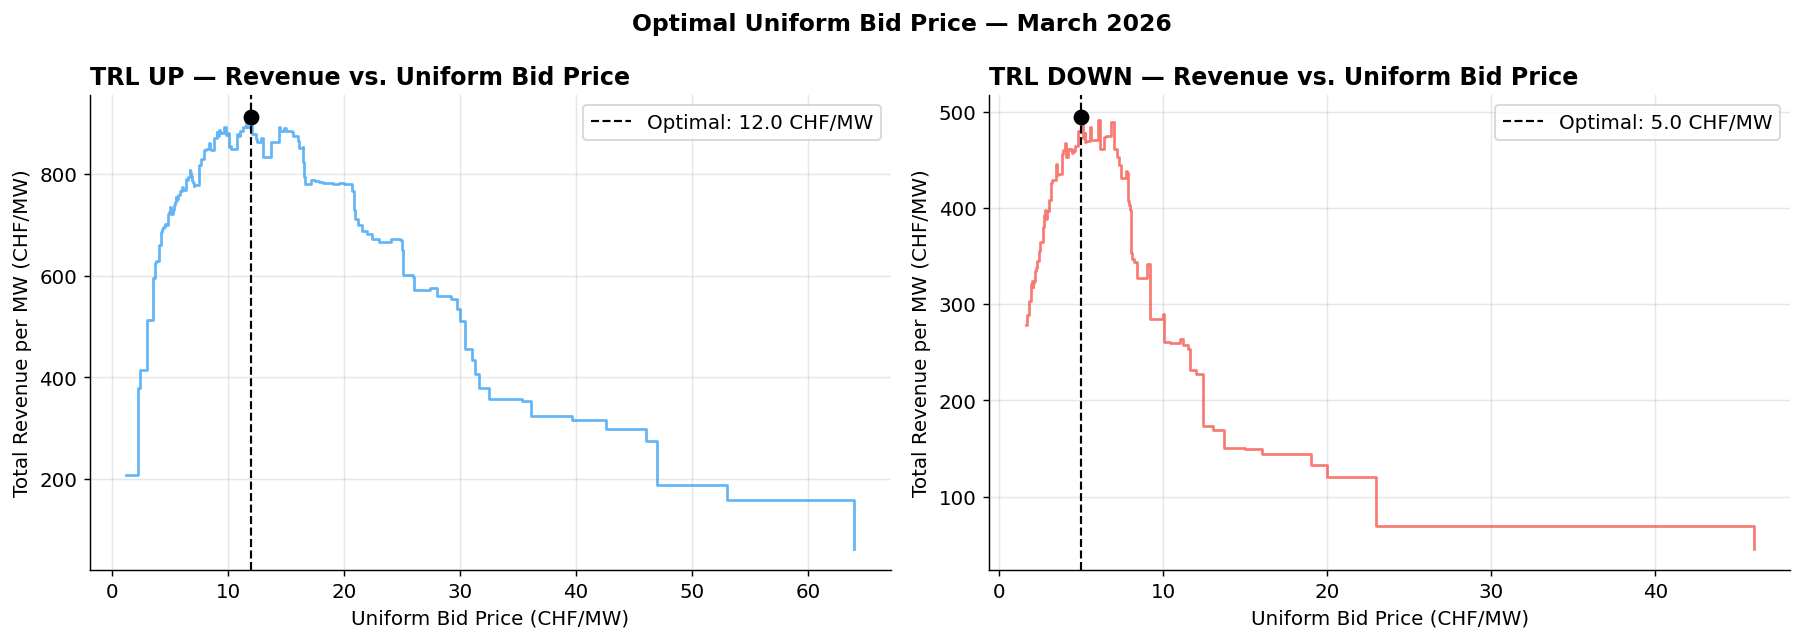

In [45]:
results = {}

for direction in ["UP", "DOWN"]:
    prices = marginal[marginal["Direction"] == direction]["Marginal_Price"].values
    total_blocks = len(prices)

    candidates = np.sort(np.unique(prices))
    revenues   = np.array([p * np.sum(prices >= p) for p in candidates])

    best_idx   = np.argmax(revenues)
    best_price = candidates[best_idx]
    best_rev   = revenues[best_idx]
    n_accepted = int(np.sum(prices >= best_price))

    results[direction] = dict(
        best_price=best_price,
        n_accepted=n_accepted,
        total_blocks=total_blocks,
        revenue_per_mw=best_rev,
        candidates=candidates,
        revenues=revenues,
    )

    print(f"── TRL {direction} ──")
    print(f"  Total (Date × Block) slots : {total_blocks}")
    print(f"  Optimal single bid price   : {best_price:.2f} CHF/MW")
    print(f"  Blocks accepted            : {n_accepted} / {total_blocks}  ({n_accepted/total_blocks:.1%})")
    print(f"  Revenue per MW (month)     : {best_rev:,.1f} CHF/MW")
    print(f"    = {best_price:.2f} CHF/MW × {n_accepted} blocks × 4 h")
    print()

# ── Plot: revenue curve vs. bid price ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, direction, color in zip(axes, ["UP", "DOWN"], ["#2196F3", "#F44336"]):
    r = results[direction]
    ax.step(r["candidates"], r["revenues"], where="post", color=color, linewidth=1.5, alpha=0.7)
    ax.axvline(r["best_price"], color="black", linestyle="--", linewidth=1.2, label=f"Optimal: {r['best_price']:.1f} CHF/MW")
    ax.scatter([r["best_price"]], [r["revenue_per_mw"]], color="black", zorder=5, s=60)
    ax.set_title(f"TRL {direction} — Revenue vs. Uniform Bid Price", fontweight="bold", loc="left")
    ax.set_xlabel("Uniform Bid Price (CHF/MW)")
    ax.set_ylabel("Total Revenue per MW (CHF/MW)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend()

fig.suptitle("Optimal Uniform Bid Price — March 2026", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 9. Optimal Bid Price per Time Block (Uniform Across Days)

Relaxing the constraint: we now allow a **different price per time block**, but still one price per block that must hold across all days in March.

> For each block: Maximise `bid_price × N_days_accepted`

── TRL UP ──
  00:00 bis 04:00  optimal bid:   3.48 CHF/MW  accepted: 27/29 days  rev/MW:    94.0 CHF
  04:00 bis 08:00  optimal bid:  11.56 CHF/MW  accepted: 16/29 days  rev/MW:   185.0 CHF
  08:00 bis 12:00  optimal bid:  16.48 CHF/MW  accepted: 13/29 days  rev/MW:   214.2 CHF
  12:00 bis 16:00  optimal bid:   9.36 CHF/MW  accepted: 18/29 days  rev/MW:   168.5 CHF
  16:00 bis 20:00  optimal bid:  24.00 CHF/MW  accepted: 11/29 days  rev/MW:   264.0 CHF
  20:00 bis 24:00  optimal bid:   8.36 CHF/MW  accepted: 17/29 days  rev/MW:   142.1 CHF
  ── Total revenue per MW (month): 1,067.8 CHF/MW

── TRL DOWN ──
  00:00 bis 04:00  optimal bid:   6.80 CHF/MW  accepted: 10/29 days  rev/MW:    68.0 CHF
  04:00 bis 08:00  optimal bid:   3.20 CHF/MW  accepted: 20/29 days  rev/MW:    64.0 CHF
  08:00 bis 12:00  optimal bid:   7.00 CHF/MW  accepted: 17/29 days  rev/MW:   119.0 CHF
  12:00 bis 16:00  optimal bid:   6.80 CHF/MW  accepted: 22/29 days  rev/MW:   149.6 CHF
  16:00 bis 20:00  optimal bid:

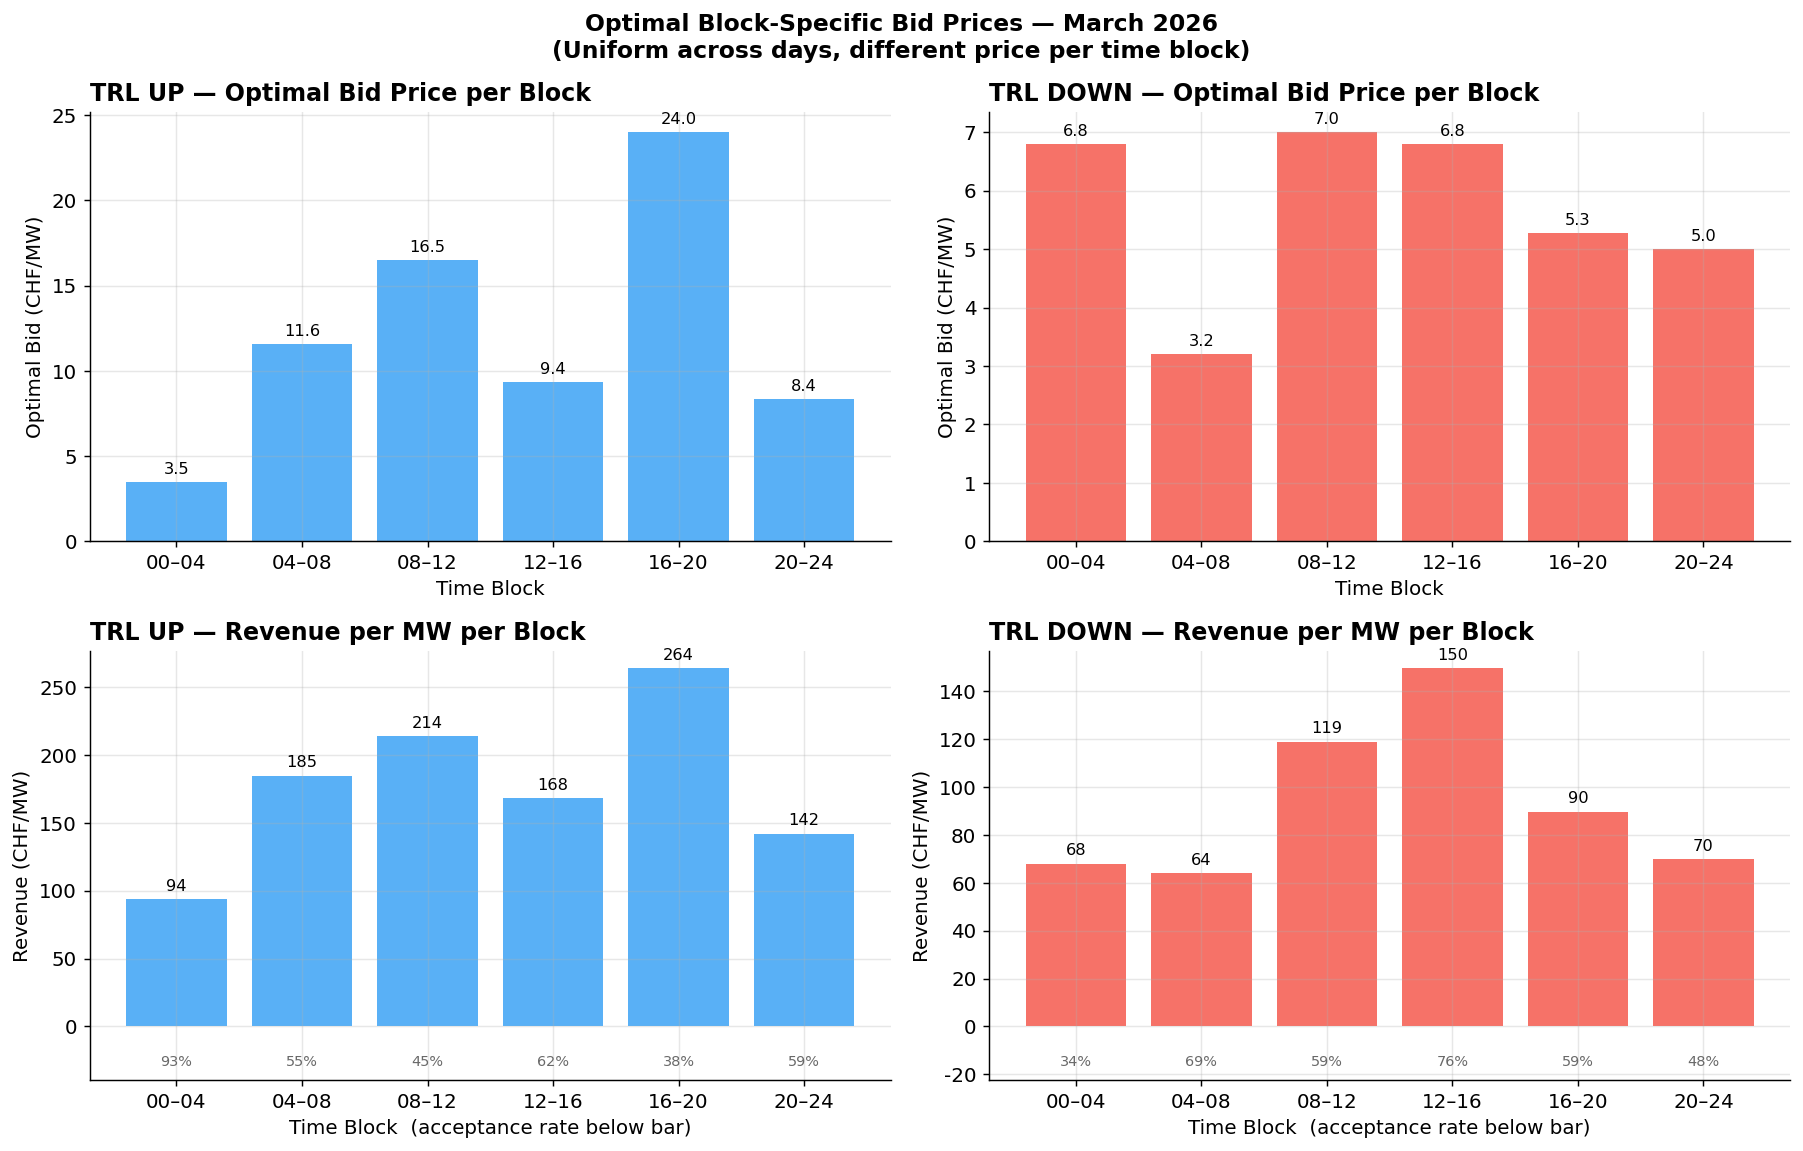

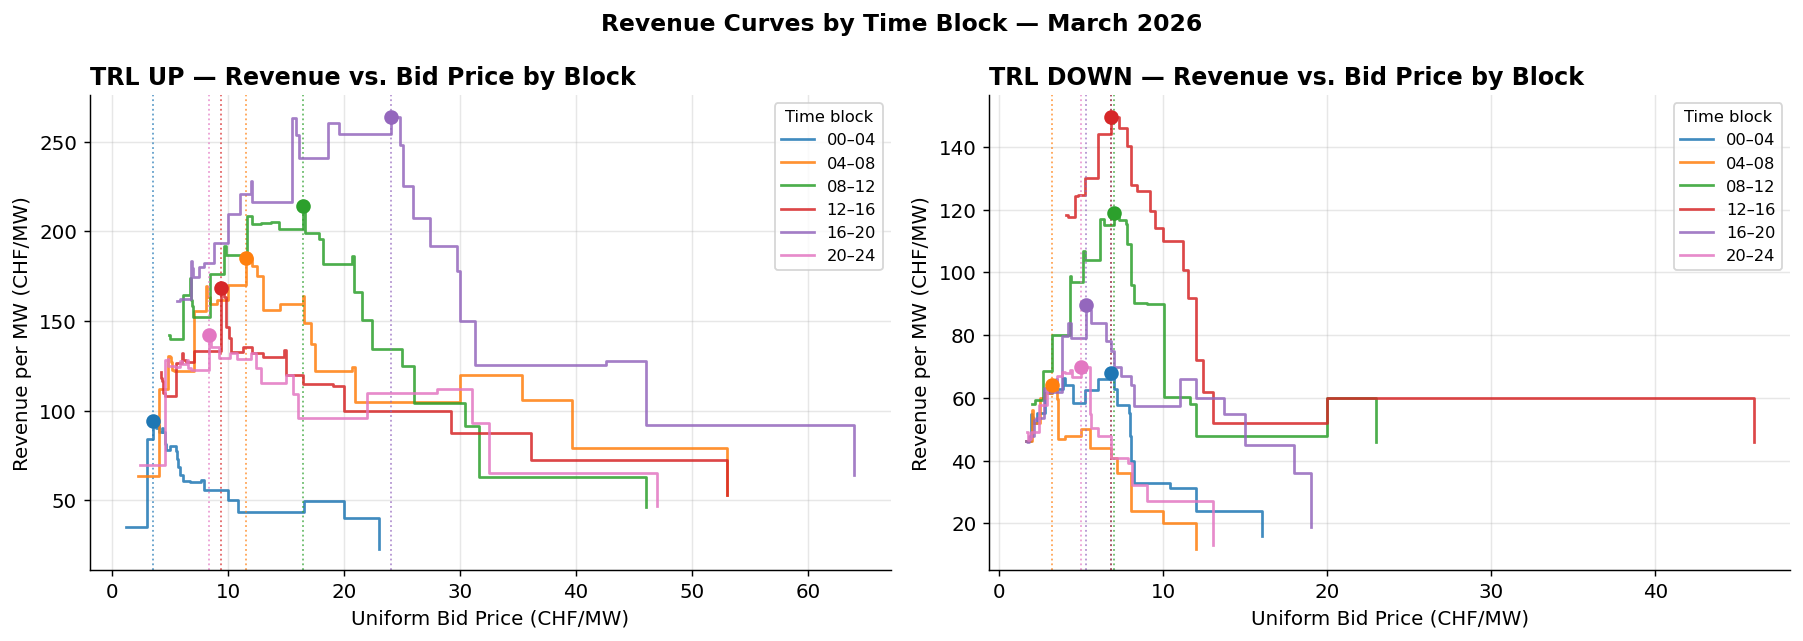

In [46]:
block_order  = ["00:00 bis 04:00", "04:00 bis 08:00", "08:00 bis 12:00",
                "12:00 bis 16:00", "16:00 bis 20:00", "20:00 bis 24:00"]
block_labels = ["00–04", "04–08", "08–12", "12–16", "16–20", "20–24"]

results_block = {}

for direction in ["UP", "DOWN"]:
    block_results = {}
    total_rev = 0

    for block in block_order:
        prices = marginal[
            (marginal["Direction"] == direction) &
            (marginal["Block"] == block)
        ]["Marginal_Price"].values

        if len(prices) == 0:
            continue

        candidates = np.sort(np.unique(prices))
        revenues   = np.array([p * np.sum(prices >= p) for p in candidates])

        best_idx   = np.argmax(revenues)
        best_price = candidates[best_idx]
        best_rev   = revenues[best_idx]
        n_accepted = int(np.sum(prices >= best_price))

        block_results[block] = dict(
            best_price=best_price,
            n_accepted=n_accepted,
            n_days=len(prices),
            revenue_per_mw=best_rev,
            candidates=candidates,
            revenues=revenues,
        )
        total_rev += best_rev

    results_block[direction] = dict(blocks=block_results, total_rev=total_rev)

    print(f"── TRL {direction} ──")
    for block, r in block_results.items():
        print(f"  {block}  optimal bid: {r['best_price']:>6.2f} CHF/MW"
              f"  accepted: {r['n_accepted']:>2}/{r['n_days']} days"
              f"  rev/MW: {r['revenue_per_mw']:>7.1f} CHF")
    print(f"  ── Total revenue per MW (month): {total_rev:,.1f} CHF/MW")
    print()

# ── Plot 1: bar charts — optimal bid price & revenue per block ─────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, (direction, color) in enumerate(zip(["UP", "DOWN"], ["#2196F3", "#F44336"])):
    br = results_block[direction]["blocks"]

    opt_prices = [br[b]["best_price"]     for b in block_order]
    revenues   = [br[b]["revenue_per_mw"] for b in block_order]
    acc_pct    = [br[b]["n_accepted"] / br[b]["n_days"] for b in block_order]

    ax = axes[0, col]
    bars = ax.bar(block_labels, opt_prices, color=color, alpha=0.75)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_title(f"TRL {direction} — Optimal Bid Price per Block", fontweight="bold", loc="left")
    ax.set_ylabel("Optimal Bid (CHF/MW)")
    ax.set_xlabel("Time Block")

    ax = axes[1, col]
    bars = ax.bar(block_labels, revenues, color=color, alpha=0.75)
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)
    for i, pct in enumerate(acc_pct):
        ax.text(i, -max(revenues) * 0.08, f"{pct:.0%}", ha="center", va="top",
                fontsize=8, color="dimgray")
    ax.set_title(f"TRL {direction} — Revenue per MW per Block", fontweight="bold", loc="left")
    ax.set_ylabel("Revenue (CHF/MW)")
    ax.set_xlabel("Time Block  (acceptance rate below bar)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.set_ylim(bottom=-max(revenues) * 0.15)

fig.suptitle(
    "Optimal Block-Specific Bid Prices — March 2026\n"
    "(Uniform across days, different price per time block)",
    fontsize=13, fontweight="bold"
)
fig.tight_layout()
plt.show()

# ── Plot 2: revenue curves — one curve per time block ─────────────────────
block_palette = plt.cm.tab10(np.linspace(0, 0.6, len(block_order)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, direction in zip(axes, ["UP", "DOWN"]):
    br = results_block[direction]["blocks"]
    for i, block in enumerate(block_order):
        r = br[block]
        c = block_palette[i]
        ax.step(r["candidates"], r["revenues"], where="post",
                color=c, linewidth=1.5, alpha=0.85, label=block_labels[i])
        ax.axvline(r["best_price"], color=c, linestyle=":", linewidth=1, alpha=0.7)
        ax.scatter([r["best_price"]], [r["revenue_per_mw"]], color=c, zorder=5, s=50)

    ax.set_title(f"TRL {direction} — Revenue vs. Bid Price by Block", fontweight="bold", loc="left")
    ax.set_xlabel("Uniform Bid Price (CHF/MW)")
    ax.set_ylabel("Revenue per MW (CHF/MW)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(title="Time block", fontsize=9, title_fontsize=9)

fig.suptitle("Revenue Curves by Time Block — March 2026", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 10. Helion Bid Comparison vs. Marginal Clearing Price

Load our actual submitted bids (`Zuschläge.csv`) and compare each slot against the market marginal clearing price.

Bids are classified into four cases:
| Bid vs. Marginal | Accepted | Label |
|---|---|---|
| bid ≤ marginal | yes | Correct acceptance |
| bid ≤ marginal | no  | **Missed** (platform pre-processing) |
| bid > marginal | no  | Correct rejection |
| bid > marginal | yes | Partial fill at margin |

> **Note on units:** `Leistungspreis` in `Zuschläge.csv` is labelled CHF/MWh; the market `Marginal_Price` is in CHF/MW per 4 h block. To compare them on the same axis we multiply our bid by 4 (CHF/MWh × 4 h = CHF/MW). Verify this with your trading platform if uncertain.

Total bids loaded : 132  (of which zero-price: 26)
Average bid volume: 0.642 MW  (min: 0.200, max: 1.400)

── Classification summary ──
Category
Correct rejection     48
Correct acceptance    46
Missed (platform)     38

Revenue earned (actual)                   :     183.99 CHF
Revenue potential (sub-marg at bid price)  :     235.51 CHF
Revenue maximum (always bid at marginal)   :     502.58 CHF

Gap: actual vs. potential                  :      51.52 CHF  (platform misses, at our bid price)
Gap: actual vs. maximum                    :     318.60 CHF  (total upside incl. pricing strategy)


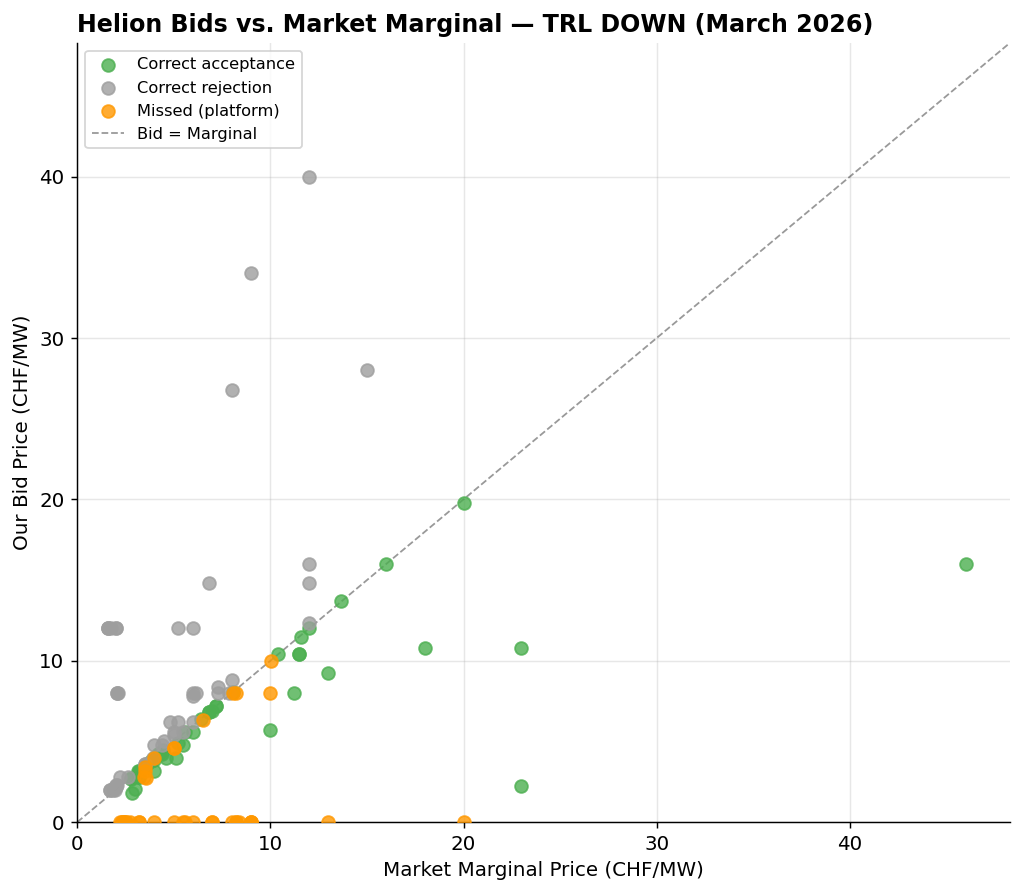

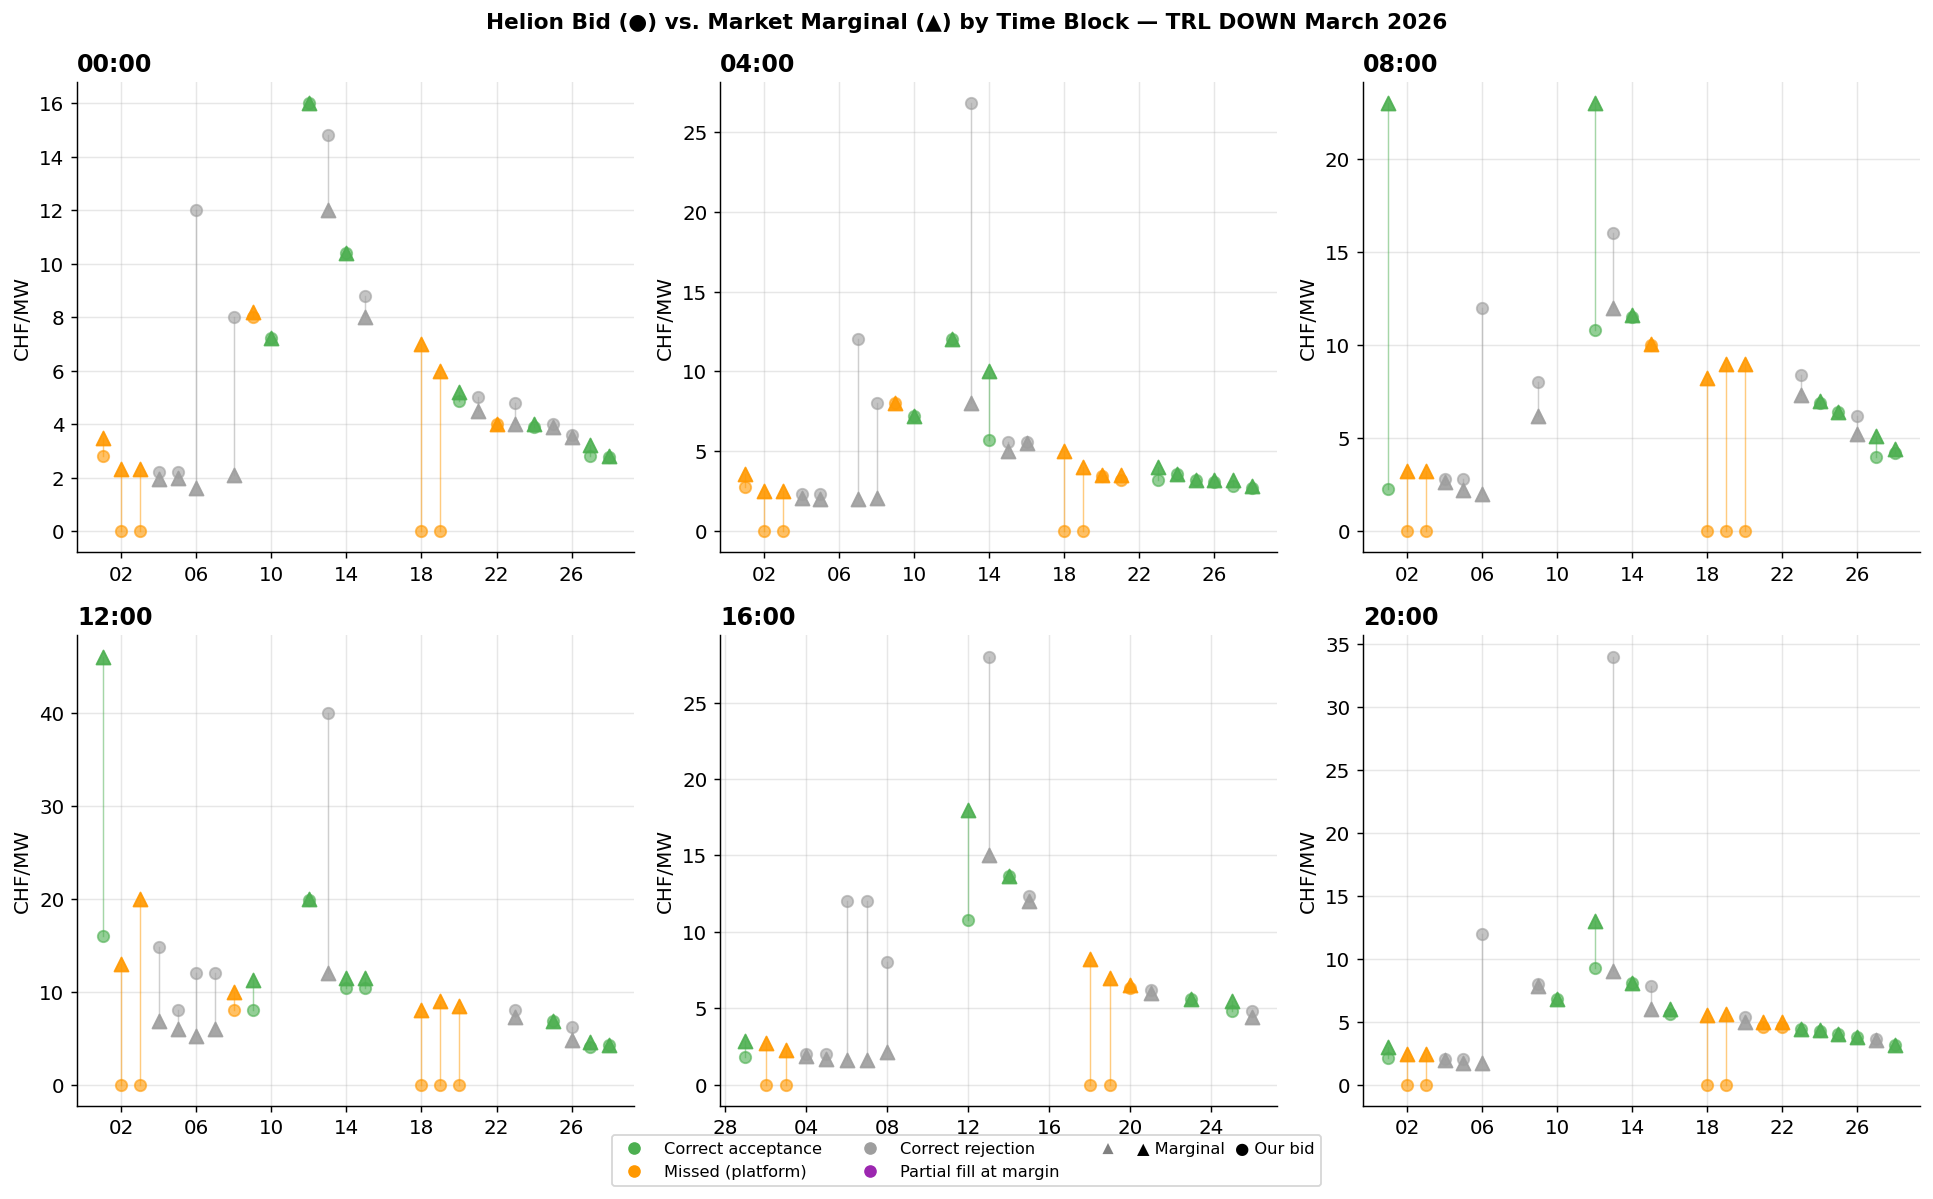

In [50]:
import re

# ── Load Helion bids ───────────────────────────────────────────────────────
zuschlaege = pd.read_csv("TRL Data/Zuschläge.csv", sep=";", encoding_errors="replace")
zuschlaege.columns = zuschlaege.columns.str.strip()

zuschlaege["Date"] = pd.to_datetime(
    zuschlaege["Lieferung von"], format="%d.%m.%Y %H:%M"
).dt.normalize()

def prod_to_block(prod):
    m = re.search(r"_(\d{2})-(\d{2})$", str(prod))
    return f"{m.group(1)}:00 bis {m.group(2)}:00" if m else None

zuschlaege["Block"]           = zuschlaege["Produkt"].apply(prod_to_block)
zuschlaege["Direction"]       = "DOWN"
zuschlaege["Accepted_Helion"] = zuschlaege["Status"].str.strip() == "bezuschlagt"

zuschlaege = zuschlaege.rename(columns={
    "Leistungspreis (CHF/MWh)": "Bid_CHF_MWh",
    "Leistung (MW)":             "Bid_MW",
    "Bezuschlagte Leistung (MW)":"Acc_MW",
})

zuschlaege["Bid_CHF_MW"] = zuschlaege["Bid_CHF_MWh"] * 4

# Only drop obvious placeholder "no bid" rows (price = 99 CHF/MWh)
bids = zuschlaege[
    zuschlaege["Bid_CHF_MWh"].notna() &
    (zuschlaege["Bid_CHF_MWh"] < 50)
].copy()

print(f"Total bids loaded : {len(bids)}  (of which zero-price: {(bids['Bid_CHF_MWh'] == 0).sum()})")
print(f"Average bid volume: {bids['Bid_MW'].mean():.3f} MW  (min: {bids['Bid_MW'].min():.3f}, max: {bids['Bid_MW'].max():.3f})")

# ── Join with market marginal prices ──────────────────────────────────────
marginal_down = marginal[marginal["Direction"] == "DOWN"][["Date", "Block", "Marginal_Price"]]
comp = bids.merge(marginal_down, on=["Date", "Block"], how="left")

# ── Classify each slot ────────────────────────────────────────────────────
def classify(row):
    if pd.isna(row["Marginal_Price"]):
        return "No market data"
    if row["Bid_CHF_MW"] <= row["Marginal_Price"]:
        return "Correct acceptance" if row["Accepted_Helion"] else "Missed (platform)"
    else:
        return "Partial fill at margin" if row["Accepted_Helion"] else "Correct rejection"

comp["Category"] = comp.apply(classify, axis=1)

cat_colors = {
    "Correct acceptance":    "#4CAF50",
    "Missed (platform)":     "#FF9800",
    "Correct rejection":     "#9E9E9E",
    "Partial fill at margin":"#9C27B0",
    "No market data":        "#BDBDBD",
}

print("\n── Classification summary ──")
print(comp["Category"].value_counts().to_string())
print()

# ── Revenue calculations ───────────────────────────────────────────────────
# 1. Actual: bid price × accepted MW
comp["Rev_earned"]    = np.where(comp["Accepted_Helion"],
                                  comp["Bid_CHF_MW"] * comp["Acc_MW"], 0)

# 2. Potential: bid price × bid MW for all sub-marginal slots
#    (zero-price bids contribute 0 here — accepted but earn nothing)
comp["Rev_potential"] = np.where(comp["Bid_CHF_MW"] <= comp["Marginal_Price"].fillna(np.inf),
                                  comp["Bid_CHF_MW"] * comp["Bid_MW"], 0)

# 3. Maximum: always bid exactly at marginal → always accepted, earn marginal × bid MW
comp["Rev_max"] = comp["Marginal_Price"].fillna(0) * comp["Bid_MW"]

rev_earned    = comp["Rev_earned"].sum()
rev_potential = comp["Rev_potential"].sum()
rev_max       = comp["Rev_max"].sum()

print(f"Revenue earned (actual)                   : {rev_earned:>10,.2f} CHF")
print(f"Revenue potential (sub-marg at bid price)  : {rev_potential:>10,.2f} CHF")
print(f"Revenue maximum (always bid at marginal)   : {rev_max:>10,.2f} CHF")
print()
print(f"Gap: actual vs. potential                  : {rev_potential - rev_earned:>10,.2f} CHF  (platform misses, at our bid price)")
print(f"Gap: actual vs. maximum                    : {rev_max - rev_earned:>10,.2f} CHF  (total upside incl. pricing strategy)")

# ── Plot 1: scatter — our bid vs market marginal ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for cat, grp in comp[comp["Category"] != "No market data"].groupby("Category"):
    ax.scatter(grp["Marginal_Price"], grp["Bid_CHF_MW"],
               label=cat, color=cat_colors[cat], s=50, alpha=0.8, zorder=3)

lim = max(comp["Marginal_Price"].max(), comp["Bid_CHF_MW"].max()) * 1.05
ax.plot([0, lim], [0, lim], color="black", linewidth=1, linestyle="--", alpha=0.4, label="Bid = Marginal")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Market Marginal Price (CHF/MW)")
ax.set_ylabel("Our Bid Price (CHF/MW)")
ax.set_title("Helion Bids vs. Market Marginal — TRL DOWN (March 2026)", fontweight="bold", loc="left")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# ── Plot 2: bid vs marginal by block, coloured by category ────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=False)

for ax, block in zip(axes.flat, block_order):
    df_b = comp[comp["Block"] == block]
    for cat, grp in df_b.groupby("Category"):
        ax.scatter(grp["Date"], grp["Marginal_Price"],
                   marker="^", color=cat_colors[cat], s=60, alpha=0.9, zorder=3)
        ax.scatter(grp["Date"], grp["Bid_CHF_MW"],
                   marker="o", color=cat_colors[cat], s=40, alpha=0.6, zorder=3)
        for _, row in grp.iterrows():
            if not pd.isna(row["Marginal_Price"]):
                ax.plot([row["Date"], row["Date"]],
                        [row["Bid_CHF_MW"], row["Marginal_Price"]],
                        color=cat_colors[cat], linewidth=0.8, alpha=0.5)

    ax.set_title(block[:5], fontweight="bold", loc="left")
    ax.set_ylabel("CHF/MW")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d"))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=4))

handles = [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=c, markersize=8, label=l)
           for l, c in cat_colors.items() if l != "No market data"]
handles += [plt.Line2D([0],[0], marker="^", color="w", markerfacecolor="gray", markersize=8, label="▲ Marginal  ● Our bid")]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Helion Bid (●) vs. Market Marginal (▲) by Time Block — TRL DOWN March 2026",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()